# Synthetic telemetry generation

## Packages

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

## Load dataset

In [3]:
DATA_DIR = Path("../datasets/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_files = list(DATA_DIR.glob("*.csv"))

if csv_files:
    csv_path = csv_files[0]
    print(f"Dataset already exists: {csv_path}")

df = pd.read_csv(csv_path)

print(f"Dataset loaded: {df.shape}")

Dataset already exists: ../datasets/raw/smart_manufacturing_data.csv
Dataset loaded: (100000, 13)


## Selected variable

For our synthetic data generation, we are going to focus on the following `Sensor Readings` variables:

* `Temperature`
* `Vibration`
* `Humidity`
* `Pressure`
* `Energy Consumption`

We assume that all machines are identical, which allows us to guarantee the **i.i.d. (independent and identically distributed)** assumption across machines.

In [4]:
variables = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']
df_variables = df[variables].copy()
df_variables.head()

,temperature,vibration,humidity,pressure,energy_consumption
0,78.61,28.65,79.96,3.73,2.16
1,68.19,57.28,35.94,3.64,0.69
2,98.94,50.20,72.06,1.00,2.49
3,90.91,37.65,30.34,3.15,4.96
4,72.32,40.69,56.71,2.68,0.63


## Telemetry generation techniques

We are going to explore and implement different techniques for generating synthetic telemetry data.

For each technique, we will define the number of samples we want to generate and evaluate how well the resulting synthetic data resembles the original dataset.

In [16]:
n_samples = 100000

### Empirical bootstrap / empirical resampling 

This method is based on resampling directly from the empirical dataset. Each synthetic observation is obtained by randomly selecting an existing observation from the original data, with replacement.

In [17]:
df_bootstrap = pd.DataFrame(index=range(n_samples))

for col in variables:
    df_bootstrap[col] = np.random.choice(
        df_variables[col].values,
        size=100000,
        replace=True
    )
    
df_bootstrap.head()

,temperature,vibration,humidity,pressure,energy_consumption
0,69.23,32.63,41.58,4.27,3.82
1,69.86,32.64,60.94,3.79,3.17
2,72.48,68.44,45.60,4.45,3.51
3,75.87,49.14,72.37,1.58,4.93
4,63.22,57.55,53.10,1.63,3.44


### ECDF / empirical independent

The Empirical Cumulative Distribution Function (ECDF) estimates the probability distribution directly from the observed data. Synthetic values can then be generated by sampling from this estimated distribution.

Unlike simple bootstrap resampling, this approach provides a continuous representation of the empirical distribution, allowing us to generate new values rather than being restricted to values that already appear in the dataset.

In [21]:
df_ecdf = pd.DataFrame()

U_new = np.random.uniform(
    0, 1,
    size=(n_samples, len(variables))
)

for i, col in enumerate(variables):
    values = np.sort(df_variables[col].dropna().values)

    df_ecdf[col] = np.quantile(
        values,
        U_new[:, i]
    )

df_ecdf.head()

,temperature,vibration,humidity,pressure,energy_consumption
0,77.37,50.41,48.410000,2.02,2.72
1,88.60,34.25,77.800000,1.90,1.42
2,77.12,76.20,59.616227,1.14,4.39
3,71.23,57.99,73.330000,1.07,2.61
4,85.51,55.28,55.136483,2.20,4.25


## Empirical + Gaussian Copula

This approach combines empirical distributions for the individual variables with a Gaussian copula to model the dependencies between them.

First, the empirical distribution of each variable is estimated independently. Then, the dependencies between variables are captured using a Gaussian copula. This allows us to generate synthetic observations that preserve both the individual distributions of the telemetry variables and, approximately, their correlation structure.

Overall, this method provides a more flexible approach than generating each variable independently, since it attempts to preserve the relationships observed between the different sensor measurements.

In [22]:
df_percentile = pd.DataFrame(index=df_variables.index)
df_normal = pd.DataFrame(index=df_variables.index)
df_ecdf_gaussian = pd.DataFrame(index=range(n_samples))

for col in variables:
    # Calculate the percentile rank of each value in the column
    df_percentile[col] = df_variables[col].rank(method="average", pct=True)
    # Transform the percentile ranks to a standard normal distribution using the inverse CDF (percent point function)
    df_normal[col] = stats.norm.ppf(df_percentile[col])

correlation_matrix = df_normal.corr().to_numpy()

L = np.linalg.cholesky(correlation_matrix)
random_normal = np.random.normal(
    size=(n_samples, len(variables))
)
normal_new = random_normal @ L.T

percentile_new = stats.norm.cdf(normal_new)

for i, col in enumerate(variables): 
    sorted_values = np.sort(df_variables[col].to_numpy()) 
    df_ecdf_gaussian[col] = np.quantile(sorted_values, percentile_new[:, i] )

df_ecdf_gaussian.head()

,temperature,vibration,humidity,pressure,energy_consumption
0,67.27,40.580000,47.94,1.89,0.60
1,66.61,57.500000,43.63,2.30,3.29
2,55.39,76.410000,70.73,3.14,4.03
3,75.25,78.671241,59.53,1.65,4.20
4,71.46,74.080000,63.81,3.65,3.33


## Compare Distributions

We are going to evaluate whether the different techniques work correctly for generating synthetic data.

To assess this, we will compare the distributions of the synthetic data generated by each technique with the distributions observed in the original data. This will help us determine how well each method is able to reproduce the characteristics of the original dataset.

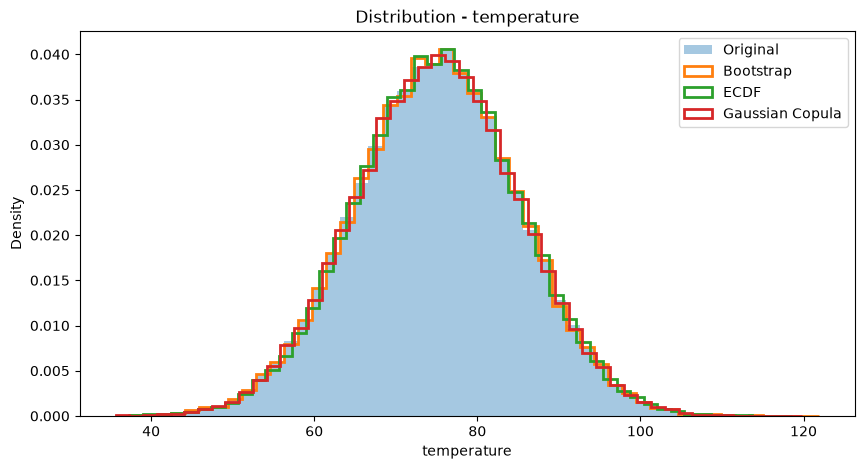

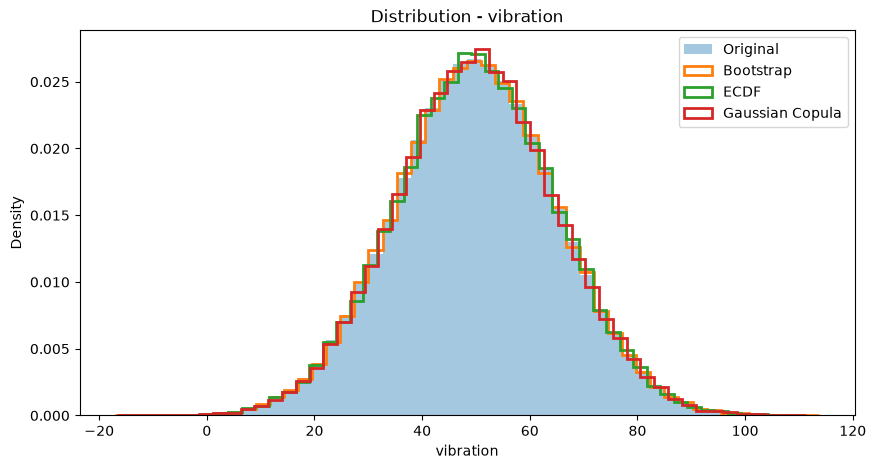

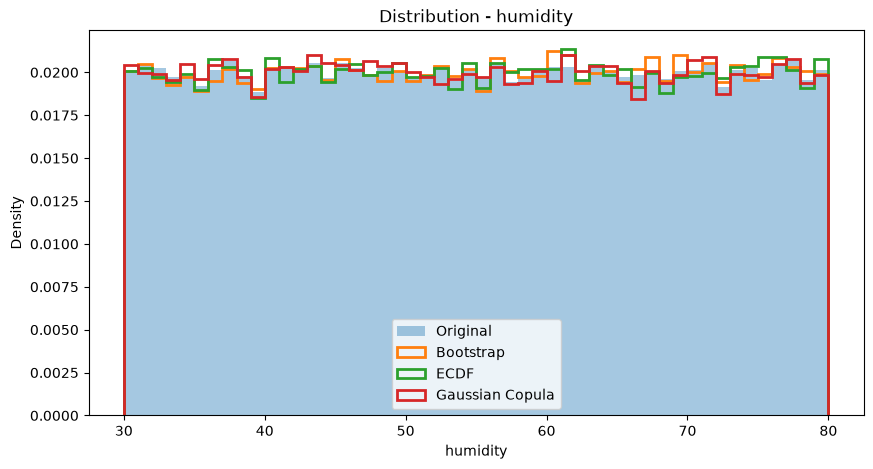

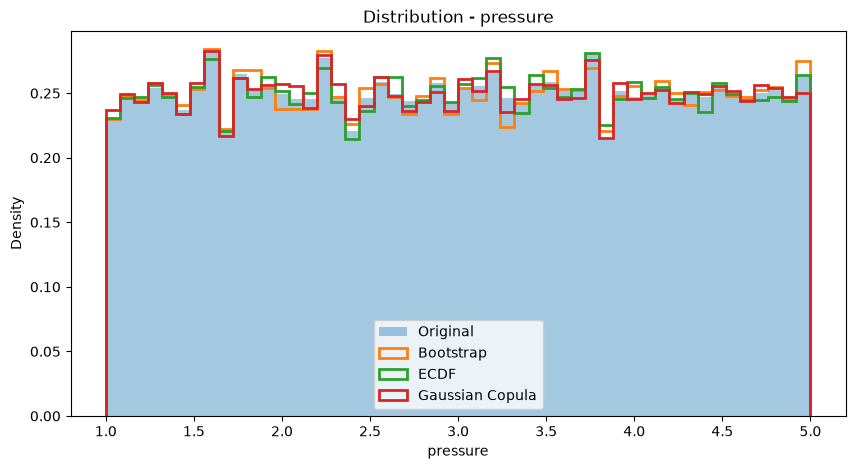

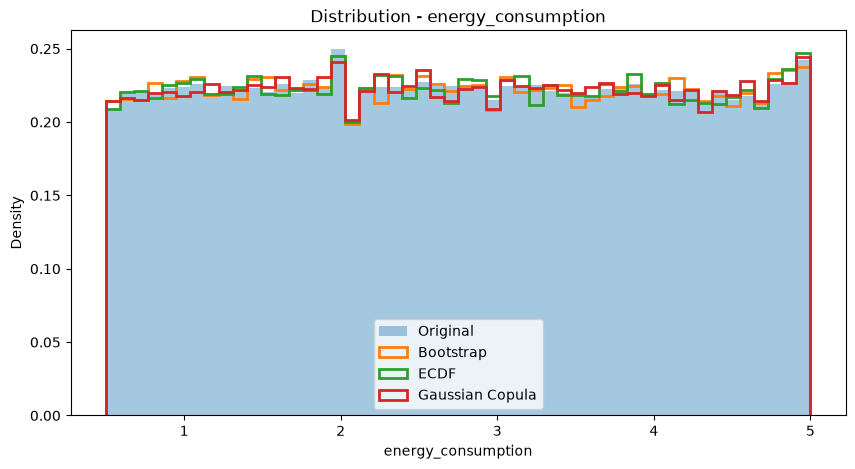

In [28]:
def plot_compare_two_distribution(original_df, synthetic_df, variables):
    for col in variables:
        plt.figure(figsize=(8, 4))

        plt.hist(original_df[col], bins=50, alpha=0.5, density=True, label="Original")
        plt.hist(synthetic_df[col], bins=50, alpha=0.5, density=True, label="Synthetic")

        plt.title(f"Distribution - {col}")
        plt.legend()
        plt.show()

def plot_compare_distribution(original_df, synthetic_dfs, variables):
    for col in variables:
        plt.figure(figsize=(10, 5))

        # Original
        plt.hist(
            original_df[col],
            bins=50,
            density=True,
            alpha=0.4,
            label="Original"
        )

        # All synthetic datasets
        for name, df in synthetic_dfs.items():
            plt.hist(
                df[col],
                bins=50,
                density=True,
                histtype="step",
                linewidth=2,
                label=name
            )

        plt.title(f"Distribution - {col}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.show()

synthetic_dfs = {
    "Bootstrap": df_bootstrap,
    "ECDF": df_ecdf,
    "Gaussian Copula": df_ecdf_gaussian
}

plot_compare_distribution(
    df_variables,
    synthetic_dfs,
    variables
)

The synthetic data generation process focuses only on the sensor-related variables, as these represent the telemetry measurements we want to simulate. The remaining variables are not included in this generation step; instead, they will be taken into account separately during the simulation and prediction stages.

## Analysis of Dependencies

We are going to analyze whether the sensor variables actually have dependencies between them.

To assess this, we need to calculate the correlations between the numerical variables.

To ensure that our results are reliable, we are going to apply different methods for measuring these correlations and compare their results. This will allow us to determine whether the observed relationships between the sensor variables are consistent across different correlation measures.

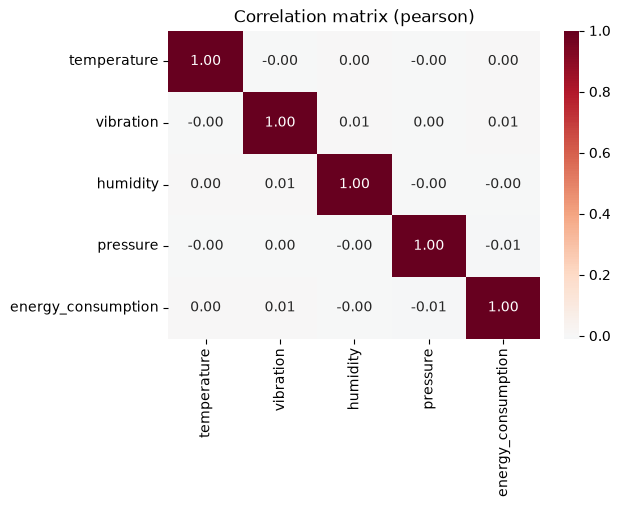

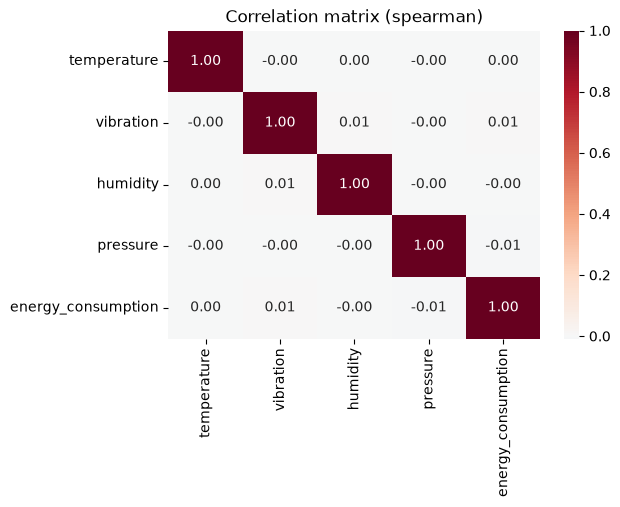

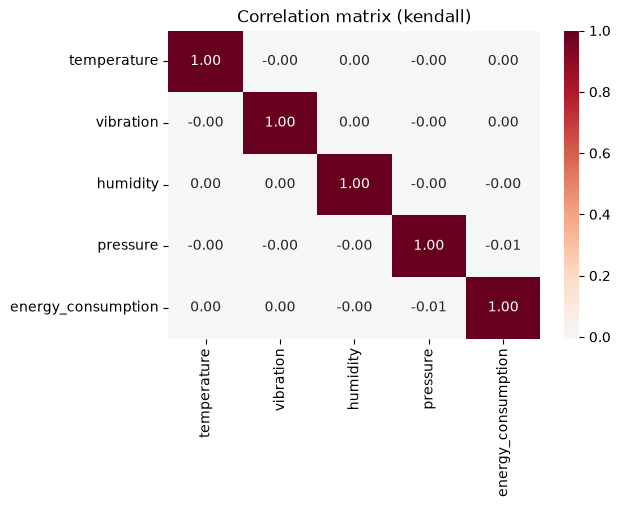

In [27]:
def plot_dependency_heatmap(df_cor, title):
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cor, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
    plt.title(title)
    plt.show()

for method in ['pearson', 'spearman', 'kendall']:
    df_correlation = df_normal.corr(method=method)
    plot_dependency_heatmap(df_correlation, f"Correlation matrix ({method})")

The five sensors show no meaningful linear correlation, and the same pattern is observed with rank-based (Spearman) correlation. Therefore, there is no evidence of monotonic dependence between the sensors. We can reasonably start by treating the sensors as independent, while recognizing that this does not mathematically prove complete independence.